# Unisolar Data EDA

Covers the rooftop solar PV dataset in **`unisolar/unisolar/`** (per-site generation, irradiance,
weather, and site metadata), the campus **calendar** (`archive/calender.csv`, holiday/semester/
exam flags), and campus **demand** data (`archive/nmi_consumption.csv` — grid connection point,
and `archive/building_consumption.csv` — summed building meters). All are keyed by campus
(`CampusKey` / `campus_id`), linked via `archive/campus_meta.csv`.

The goal driving this notebook: forecast **hourly prosumption (demand − generation)** for a single
campus, so the analysis ends by identifying which campus has the most complete, best-overlapping
generation + demand data.

The large files (multi-hundred-MB) are read with slimmer dtypes; only small per-campus summaries
are kept in memory afterwards (`del` + `gc.collect()`).

In [1]:
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyprojroot import here

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)

ROOT_DIR = here()
DATA_DIR = ROOT_DIR / "1_data" / "raw" / "unisolar_data"
SOLAR_DIR = DATA_DIR / "unisolar" / "unisolar"
ARCHIVE_DIR = DATA_DIR / "archive"

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

In [2]:
# Note: native sampling interval isn't uniformly 15-min across these files (nmi_consumption in
# particular mixes 5-min and 15-min cadence for several meters), so completeness is measured at
# hourly resolution throughout — "present" means at least one valid reading fell in that hour.
# This matches the hourly forecasting target and avoids assumptions about sub-hourly cadence.

def hourly_valid_by_campus(df, time_col, campus_col, value_col):
    """Hours (per campus) containing at least one non-missing reading."""
    valid = df.dropna(subset=[value_col, campus_col])
    return {
        campus: pd.DatetimeIndex(sub[time_col]).floor("h").unique().sort_values()
        for campus, sub in valid.groupby(campus_col)
    }


def completeness_table(hourly_valid_by_campus_dict):
    """Per-campus % of hours (over that campus's own data range) with a valid reading."""
    rows = []
    for campus, idx in hourly_valid_by_campus_dict.items():
        if len(idx) == 0:
            continue
        full_index = pd.date_range(idx.min(), idx.max(), freq="h")
        rows.append({
            "campus_id": campus,
            "start": idx.min(),
            "end": idx.max(),
            "n_expected_hours": len(full_index),
            "n_present_hours": len(idx),
            "pct_present": len(idx) / len(full_index),
        })
    return pd.DataFrame(rows)

## Campus reference

Shared lookup used throughout: campus id/name/capacity, plus the solar site metadata.

In [3]:
campus_meta = pd.read_csv(ARCHIVE_DIR / "campus_meta.csv")
campus_meta

,id,name,capacity
0,1,Bundoora,26000
1,2,Albury-Wodonga,800
2,3,Bendigo,5000
3,4,Mildura,500
4,5,Shepparton,700


In [4]:
site_details = pd.read_csv(SOLAR_DIR / "Solar_Site_Details.csv")
site_details = site_details.merge(
    campus_meta.rename(columns={"id": "CampusKey", "name": "campus_name"}),
    on="CampusKey", how="left",
)
print(f"{site_details.shape[0]} solar sites across {site_details['CampusKey'].nunique()} campuses")
site_details[["CampusKey", "campus_name", "SiteKey", "kWp", "Number of panels", "lat", "Lon"]]

42 solar sites across 5 campuses


,CampusKey,campus_name,SiteKey,kWp,Number of panels,lat,Lon
0,2,Albury-Wodonga,1,NaN,NaN,-36.111209,146.848679
1,2,Albury-Wodonga,2,NaN,NaN,-36.111209,146.848679
2,2,Albury-Wodonga,3,NaN,NaN,-36.111209,146.848679
3,2,Albury-Wodonga,4,NaN,NaN,-36.111209,146.848679
4,2,Albury-Wodonga,5,NaN,NaN,-36.111209,146.848679
5,3,Bendigo,6,NaN,NaN,-36.778858,144.301232
6,3,Bendigo,7,NaN,NaN,-36.778858,144.301232
7,3,Bendigo,8,NaN,NaN,-36.778858,144.301232
8,3,Bendigo,9,NaN,NaN,-36.778858,144.301232
9,3,Bendigo,10,NaN,NaN,-36.778858,144.301232


Note most sites are missing `kWp` / panel counts / inverter details — capacity metadata is
sparse and can't be relied on for per-site normalisation without cleaning.

## 1. Solar PV dataset (`unisolar/unisolar/`)

### 1.1 Monthly summary

In [5]:
monthly_summary = pd.read_csv(SOLAR_DIR / "Monthly_Summary_Solar.csv")
monthly_summary["Month"] = pd.Categorical(monthly_summary["Month"], categories=MONTH_ORDER, ordered=True)
monthly_summary["period"] = pd.to_datetime(
    monthly_summary["Year"].astype(str) + "-" + monthly_summary["Month"].astype(str), format="%Y-%B"
)
monthly_summary = monthly_summary.merge(
    site_details[["SiteKey", "CampusKey", "campus_name"]], on="SiteKey", how="left"
)
monthly_summary.describe()

,SiteKey,Year,AverageSolarGeneration,MaxSolarGeneration,MinSolarGeneration,period,CampusKey
count,1176.000000,1176.000000,976.000000,976.000000,976.000000,1176,1176.000000
mean,21.500000,2020.714286,6.551887,16.933539,0.109027,2021-02-14 18:51:25.714285,1.666667
min,1.000000,2020.000000,0.467732,1.207031,0.100000,2020-01-01 00:00:00,1.000000
25%,11.000000,2020.000000,2.529455,6.542969,0.101562,2020-07-24 06:00:00,1.000000
50%,21.500000,2021.000000,4.387570,12.042969,0.101581,2021-02-15 00:00:00,1.000000
75%,32.000000,2021.000000,7.014564,17.708984,0.113281,2021-09-08 12:00:00,2.000000
max,42.000000,2022.000000,43.907113,99.218800,0.321289,2022-04-01 00:00:00,5.000000
std,12.126075,0.700152,7.565232,19.664548,0.012178,NaN,1.016181


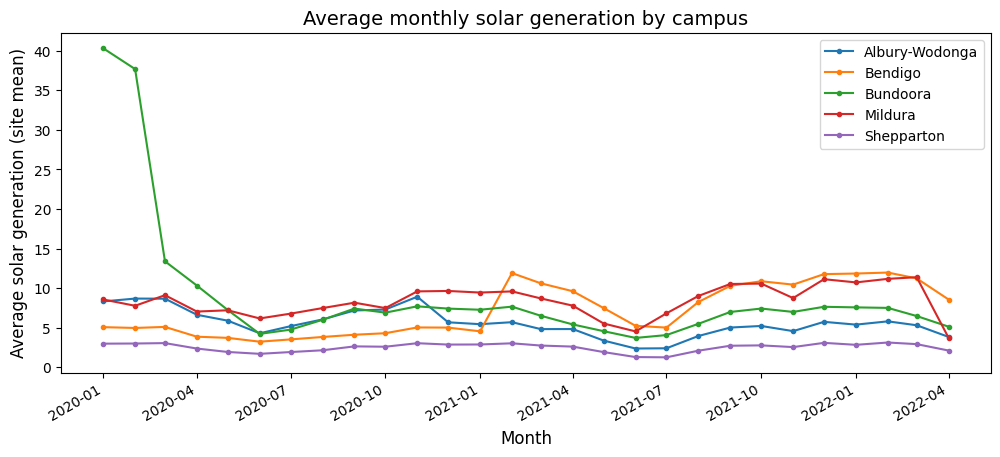

In [6]:
fig, ax = plt.subplots()
for campus_name, grp in monthly_summary.groupby("campus_name"):
    monthly = grp.groupby("period")["AverageSolarGeneration"].mean().sort_index()
    ax.plot(monthly.index, monthly.values, marker="o", markersize=3, label=campus_name)
ax.set_title("Average monthly solar generation by campus", fontsize=14)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average solar generation (site mean)", fontsize=12)
ax.legend()
fig.autofmt_xdate()
plt.show()

### 1.2 Solar energy generation (15-min interval, ~2.7M rows)

In [7]:
solar_gen = pd.read_csv(
    SOLAR_DIR / "Solar_Energy_Generation.csv",
    dtype={"CampusKey": "int16", "SiteKey": "int16", "SolarGeneration": "float32"},
    parse_dates=["Timestamp"],
).rename(columns={"CampusKey": "campus_id"})
print(f"shape: {solar_gen.shape}")
print(f"date range: {solar_gen['Timestamp'].min()} to {solar_gen['Timestamp'].max()}")
print(f"missing SolarGeneration: {solar_gen['SolarGeneration'].isna().mean():.1%}")
solar_gen.groupby("campus_id")["SolarGeneration"].apply(lambda s: s.isna().mean()).rename("pct_missing")

shape: (2731946, 4)
date range: 2020-01-01 00:15:00 to 2022-04-23 23:45:00
missing SolarGeneration: 56.2%


campus_id
1    0.558663
2    0.553466
3    0.586170
4    0.530844
5    0.554558
Name: pct_missing, dtype: float64

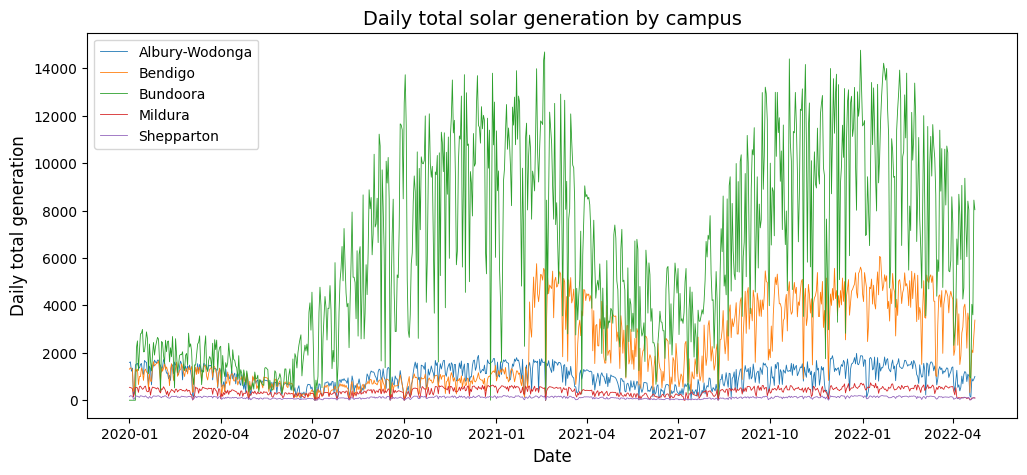

In [8]:
solar_gen["date"] = solar_gen["Timestamp"].dt.floor("D")
daily_campus_gen = (
    solar_gen.groupby(["campus_id", "date"])["SolarGeneration"].sum().reset_index()
    .merge(campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id")
)

fig, ax = plt.subplots()
for campus_name, grp in daily_campus_gen.groupby("campus_name"):
    ax.plot(grp["date"], grp["SolarGeneration"], linewidth=0.6, label=campus_name)
ax.set_title("Daily total solar generation by campus", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Daily total generation", fontsize=12)
ax.legend()
plt.show()

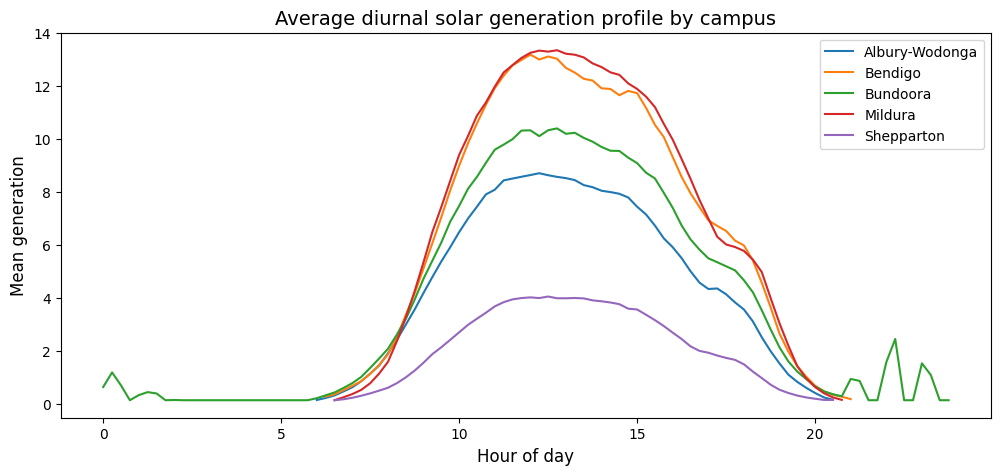

In [9]:
solar_gen["hour"] = solar_gen["Timestamp"].dt.hour + solar_gen["Timestamp"].dt.minute / 60
diurnal_gen = (
    solar_gen.groupby(["campus_id", "hour"])["SolarGeneration"].mean().reset_index()
    .merge(campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id")
)

fig, ax = plt.subplots()
for campus_name, grp in diurnal_gen.groupby("campus_name"):
    ax.plot(grp["hour"], grp["SolarGeneration"], label=campus_name)
ax.set_title("Average diurnal solar generation profile by campus", fontsize=14)
ax.set_xlabel("Hour of day", fontsize=12)
ax.set_ylabel("Mean generation", fontsize=12)
ax.legend()
plt.show()

In [10]:
# Keep only lightweight per-campus timestamp summaries before freeing the raw 2.7M-row frame
solar_hourly = hourly_valid_by_campus(solar_gen, "Timestamp", "campus_id", "SolarGeneration")
solar_completeness = completeness_table(solar_hourly)

del solar_gen, daily_campus_gen, diurnal_gen
gc.collect()
solar_completeness

,campus_id,start,end,n_expected_hours,n_present_hours,pct_present
0,1,2020-01-08 09:00:00,2022-04-23 23:00:00,20079,10844,0.540067
1,2,2020-01-01 06:00:00,2022-04-23 17:00:00,20244,10441,0.515758
2,3,2020-01-01 06:00:00,2022-04-23 17:00:00,20244,10502,0.518771
3,4,2020-01-01 06:00:00,2022-04-23 17:00:00,20244,10138,0.500790
4,5,2020-01-01 06:00:00,2022-04-23 17:00:00,20244,9691,0.478710


### 1.3 Solar irradiance (hourly GHI / cloud opacity)

In [11]:
irradiance = pd.read_csv(SOLAR_DIR / "Solar_Irradiance.csv", parse_dates=["Timestamp_UTC"])
print(f"shape: {irradiance.shape}, campuses: {irradiance['Campus'].unique().tolist()}")
irradiance[["CloudOpacity", "Ghi"]].describe()

shape: (102360, 4), campuses: ['Bundoora', 'Bendigo', 'Wodonga', 'Mildura', 'Shepparton']


,CloudOpacity,Ghi
count,102360.000000,102360.000000
mean,21.507004,206.405676
std,27.211402,295.262852
min,0.000000,0.000000
25%,0.000000,0.000000
50%,5.900000,11.000000
75%,39.900000,359.000000
max,97.000000,1128.000000


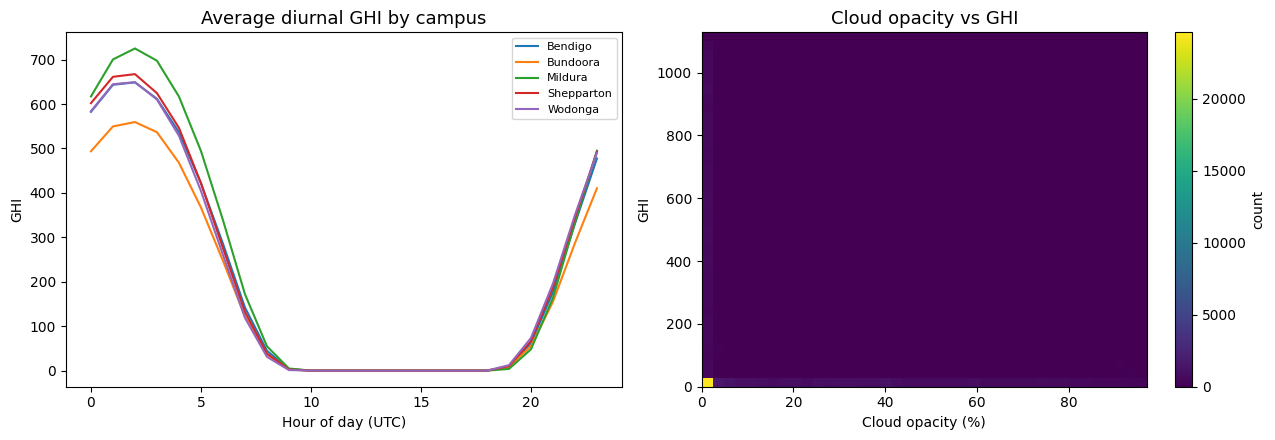

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

irradiance["hour"] = irradiance["Timestamp_UTC"].dt.hour
diurnal_ghi = irradiance.groupby(["Campus", "hour"])["Ghi"].mean().reset_index()
for campus, grp in diurnal_ghi.groupby("Campus"):
    axes[0].plot(grp["hour"], grp["Ghi"], label=campus)
axes[0].set_title("Average diurnal GHI by campus", fontsize=13)
axes[0].set_xlabel("Hour of day (UTC)")
axes[0].set_ylabel("GHI")
axes[0].legend(fontsize=8)

hb = axes[1].hist2d(irradiance["CloudOpacity"], irradiance["Ghi"], bins=40, cmap="viridis")
fig.colorbar(hb[3], ax=axes[1], label="count")
axes[1].set_title("Cloud opacity vs GHI", fontsize=13)
axes[1].set_xlabel("Cloud opacity (%)")
axes[1].set_ylabel("GHI")

plt.tight_layout()
plt.show()

### 1.4 Weather at solar sites (15-min interval)

In [13]:
solar_weather = pd.read_csv(SOLAR_DIR / "Weather_Data_reordered_all.csv", parse_dates=["Timestamp"])
solar_weather = solar_weather.merge(
    campus_meta.rename(columns={"id": "CampusKey", "name": "campus_name"}), on="CampusKey", how="left"
)
print(f"shape: {solar_weather.shape}")
solar_weather.describe()

shape: (371769, 10)


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,capacity
count,371769.000000,371769,264656.000000,264656.000000,264656.000000,264656.000000,208879.000000,208879.000000,371769.000000
mean,2.820770,2021-03-20 05:20:21.744147,13.650350,15.938391,8.673759,68.011266,11.008896,182.316282,7128.727247
min,1.000000,2020-01-01 00:00:00,-6.633333,-2.706667,-11.473333,3.066667,0.000000,0.000000,500.000000
25%,2.000000,2020-08-30 00:45:00,8.000000,10.640000,5.613333,50.000000,5.893333,120.600000,700.000000
50%,3.000000,2021-04-01 16:00:00,12.826667,15.126667,8.326667,70.000000,10.400000,183.466667,800.000000
75%,4.000000,2021-10-12 07:00:00,18.893333,20.573333,11.513333,89.933333,15.660000,251.866667,5000.000000
max,5.000000,2022-04-23 22:00:00,41.586667,45.400000,25.320000,100.000000,56.400000,358.066667,26000.000000
std,1.337405,NaN,7.592948,7.380726,4.438691,24.060571,7.383479,88.438540,10109.517219


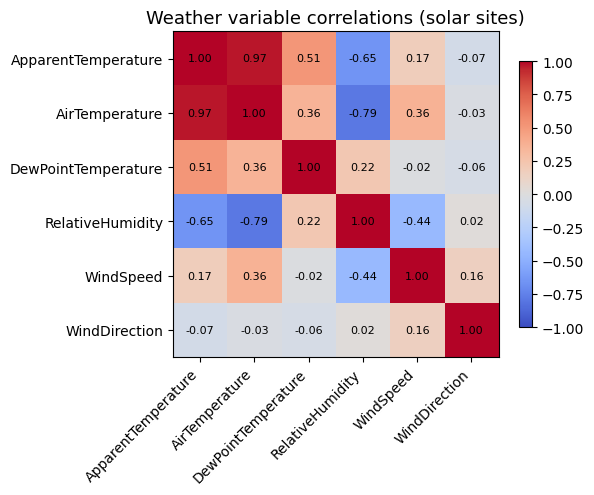

3985

In [14]:
numeric_cols = ["ApparentTemperature", "AirTemperature", "DewPointTemperature",
                "RelativeHumidity", "WindSpeed", "WindDirection"]
corr = solar_weather[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Weather variable correlations (solar sites)", fontsize=13)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

del solar_weather
gc.collect()

## 2. Campus calendar (`archive/calender.csv`) — holidays, semester and exam periods

In [15]:
calendar = pd.read_csv(ARCHIVE_DIR / "calender.csv", parse_dates=["date"])
print(f"date range: {calendar['date'].min().date()} to {calendar['date'].max().date()}")
calendar[["is_holiday", "is_semester", "is_exam"]].mean().rename("share_of_days")

date range: 2016-01-01 to 2022-04-30


is_holiday     0.033304
is_semester    0.120242
is_exam        0.050173
Name: share_of_days, dtype: float64

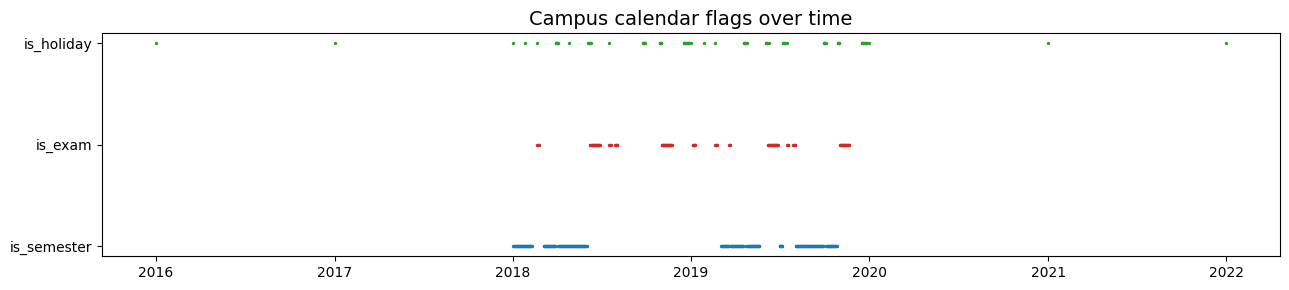

In [16]:
fig, ax = plt.subplots(figsize=(13, 3))
for flag, color, y in [("is_semester", "tab:blue", 0), ("is_exam", "tab:red", 1), ("is_holiday", "tab:green", 2)]:
    active = calendar.loc[calendar[flag] == 1, "date"]
    ax.scatter(active, [y] * len(active), s=2, color=color, label=flag)
ax.set_yticks([0, 1, 2], ["is_semester", "is_exam", "is_holiday"])
ax.set_title("Campus calendar flags over time", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Campus demand data (`archive/`)

Two demand sources, at different levels:

- **NMI consumption** (`nmi_consumption.csv`) — readings at the grid connection point (National
  Metering Identifier). This is the true whole-of-campus grid import and the standard basis for
  netting against generation.
- **Building consumption** (`building_consumption.csv`) — individual building/room meters, summed
  to a campus total. This only reflects *monitored* buildings, so a campus total here can
  understate true demand if coverage is incomplete — it's included as a cross-check against NMI,
  not a replacement for it.

### 3.1 NMI consumption — grid connection point demand (~168MB)

In [17]:
nmi_meta = pd.read_csv(ARCHIVE_DIR / "nmi_meta.csv").rename(columns={"id": "meter_id"})

nmi_cons = pd.read_csv(
    ARCHIVE_DIR / "nmi_consumption.csv",
    usecols=["campus_id", "meter_id", "timestamp", "consumption", "demand_kW"],
    dtype={"meter_id": "int16", "consumption": "float32", "demand_kW": "float32"},
    parse_dates=["timestamp"],
)
# ~4.4% of rows (all meter_id 11) are missing campus_id in the raw file; recover it from the
# meter -> campus mapping in nmi_meta rather than dropping that data.
n_missing_before = nmi_cons["campus_id"].isna().sum()
nmi_cons = nmi_cons.drop(columns="campus_id").merge(nmi_meta[["meter_id", "campus_id"]], on="meter_id", how="left")
nmi_cons["campus_id"] = nmi_cons["campus_id"].astype("Int16")
print(f"shape: {nmi_cons.shape}")
print(f"date range: {nmi_cons['timestamp'].min()} to {nmi_cons['timestamp'].max()}")
print(f"campus_id missing before recovery: {n_missing_before} ({n_missing_before / len(nmi_cons):.1%})")
print(f"campus_id still missing after recovery via nmi_meta: {nmi_cons['campus_id'].isna().sum()}")
print(f"missing demand_kW: {nmi_cons['demand_kW'].isna().mean():.2%}")
nmi_cons[["consumption", "demand_kW"]].describe()

shape: (3507076, 5)
date range: 2015-01-01 00:00:00 to 2022-04-30 00:00:00
campus_id missing before recovery: 154167 (4.4%)
campus_id still missing after recovery via nmi_meta: 0
missing demand_kW: 0.00%


,consumption,demand_kW
count,3.507076e+06,3.507076e+06
mean,6.241518e+01,2.822115e+02
std,1.527963e+02,6.513594e+02
min,1.000000e-03,-3.043808e+03
25%,5.856000e+00,2.355200e+01
50%,1.200000e+01,5.286400e+01
75%,3.968000e+01,1.692800e+02
max,1.196639e+03,4.786556e+03


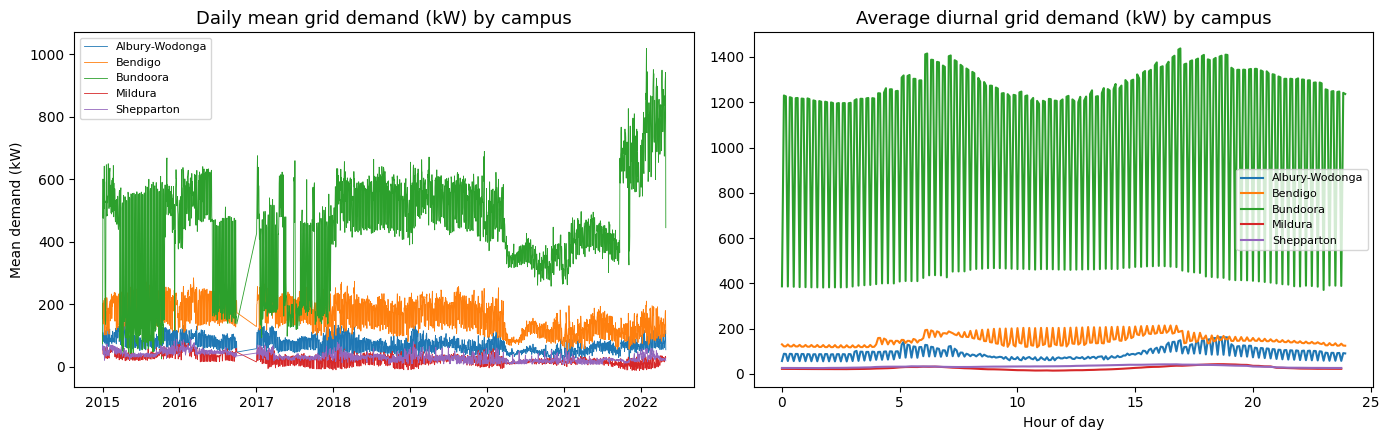

In [18]:
nmi_cons["date"] = nmi_cons["timestamp"].dt.floor("D")
nmi_cons["hour"] = nmi_cons["timestamp"].dt.hour + nmi_cons["timestamp"].dt.minute / 60

daily_demand = (
    nmi_cons.groupby(["campus_id", "date"])["demand_kW"].mean().reset_index()
    .merge(campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id")
)
diurnal_demand = (
    nmi_cons.groupby(["campus_id", "hour"])["demand_kW"].mean().reset_index()
    .merge(campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for campus_name, grp in daily_demand.groupby("campus_name"):
    axes[0].plot(grp["date"], grp["demand_kW"], linewidth=0.6, label=campus_name)
axes[0].set_title("Daily mean grid demand (kW) by campus", fontsize=13)
axes[0].set_ylabel("Mean demand (kW)")
axes[0].legend(fontsize=8)

for campus_name, grp in diurnal_demand.groupby("campus_name"):
    axes[1].plot(grp["hour"], grp["demand_kW"], label=campus_name)
axes[1].set_title("Average diurnal grid demand (kW) by campus", fontsize=13)
axes[1].set_xlabel("Hour of day")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
nmi_hourly = hourly_valid_by_campus(nmi_cons, "timestamp", "campus_id", "demand_kW")
nmi_completeness = completeness_table(nmi_hourly)

del nmi_cons, daily_demand, diurnal_demand
gc.collect()
nmi_completeness

,campus_id,start,end,n_expected_hours,n_present_hours,pct_present
0,1,2015-01-01,2022-04-30,64225,62017,0.965621
1,2,2015-01-01,2022-04-30,64225,61900,0.963799
2,3,2015-01-01,2022-04-30,64225,61835,0.962787
3,4,2015-01-01,2022-04-30,64225,60919,0.948525
4,5,2015-01-01,2022-04-30,64225,61182,0.952620


### 3.2 Building consumption — summed building meters (~252MB)

In [20]:
building_cons = pd.read_csv(
    ARCHIVE_DIR / "building_consumption.csv",
    dtype={"campus_id": "int16", "meter_id": "int32", "consumption": "float32"},
    parse_dates=["timestamp"],
)
print(f"shape: {building_cons.shape}")
print(f"date range: {building_cons['timestamp'].min()} to {building_cons['timestamp'].max()}")
print(f"missing consumption (meter-level): {building_cons['consumption'].isna().mean():.2%}")
print(f"meters per campus: {building_cons.groupby('campus_id')['meter_id'].nunique().to_dict()}")

# Campus total = sum across meters at each timestamp. min_count=1 keeps a slot NaN only if
# every meter for that campus is NaN at that timestamp (not just some of them).
building_campus = (
    building_cons.groupby(["campus_id", "timestamp"])["consumption"]
    .sum(min_count=1).reset_index()
)

shape: (8095524, 4)
date range: 2018-01-01 00:15:00 to 2022-04-30 23:45:00
missing consumption (meter-level): 0.00%
meters per campus: {1: 52, 2: 9, 3: 3}


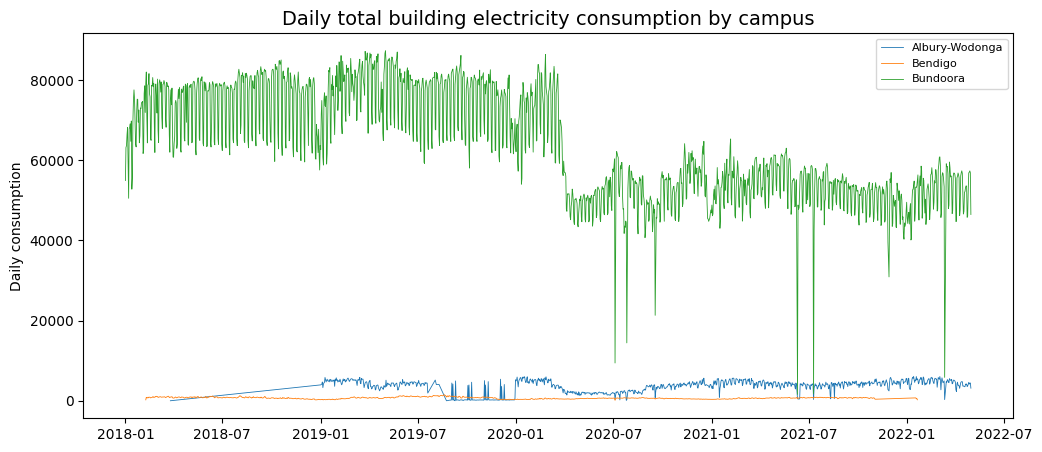

In [21]:
building_campus["date"] = building_campus["timestamp"].dt.floor("D")
daily_building = (
    building_campus.groupby(["campus_id", "date"])["consumption"].sum().reset_index()
    .merge(campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id")
)

fig, ax = plt.subplots()
for campus_name, grp in daily_building.groupby("campus_name"):
    ax.plot(grp["date"], grp["consumption"], linewidth=0.6, label=campus_name)
ax.set_title("Daily total building electricity consumption by campus", fontsize=14)
ax.set_ylabel("Daily consumption")
ax.legend(fontsize=8)
plt.show()

In [22]:
building_hourly = hourly_valid_by_campus(building_campus, "timestamp", "campus_id", "consumption")
building_completeness = completeness_table(building_hourly)

del building_cons, building_campus, daily_building
gc.collect()
building_completeness

,campus_id,start,end,n_expected_hours,n_present_hours,pct_present
0,1,2018-01-01 00:00:00,2022-04-30 23:00:00,37944,37841,0.997285
1,2,2018-03-26 00:00:00,2022-04-30 23:00:00,35928,27853,0.775245
2,3,2018-02-08 15:00:00,2022-01-20 11:00:00,34605,32758,0.946626


## 4. Missing-value analysis & campus selection for prosumption forecasting

Two complementary views (both measured at hourly resolution, since native sampling interval
isn't uniform across files — see note above the helper functions):

1. **Per-series completeness** — for each series, what fraction of its own hourly timeline (from
   first to last valid reading) actually has a reading, per campus. This surfaces sensor/meter
   dropouts within a series.
2. **Cross-series overlap** — the real constraint for prosumption modelling is having generation
   *and* demand valid in the *same* hour. This intersects each campus's set of valid hours across
   series.

In [23]:
def label_series(df, name):
    out = df.copy()
    out["series"] = name
    return out

per_series = pd.concat([
    label_series(solar_completeness, "solar_generation"),
    label_series(nmi_completeness, "nmi_demand"),
    label_series(building_completeness, "building_consumption"),
], ignore_index=True).merge(
    campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id", how="left"
)
per_series_pivot = per_series.pivot(index="campus_name", columns="series", values="pct_present")
per_series_pivot

series,building_consumption,nmi_demand,solar_generation
campus_name,,,
Albury-Wodonga,0.775245,0.963799,0.515758
Bendigo,0.946626,0.962787,0.518771
Bundoora,0.997285,0.965621,0.540067
Mildura,NaN,0.948525,0.500790
Shepparton,NaN,0.952620,0.478710


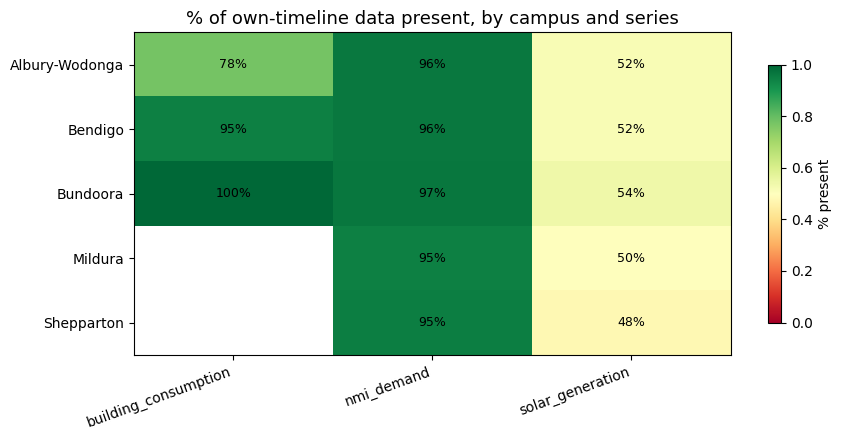

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(per_series_pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(per_series_pivot.columns)), per_series_pivot.columns, rotation=20, ha="right")
ax.set_yticks(range(len(per_series_pivot.index)), per_series_pivot.index)
for i in range(per_series_pivot.shape[0]):
    for j in range(per_series_pivot.shape[1]):
        val = per_series_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=9)
ax.set_title("% of own-timeline data present, by campus and series", fontsize=13)
fig.colorbar(im, ax=ax, shrink=0.8, label="% present")
plt.tight_layout()
plt.show()

In [25]:
campuses = sorted(set(solar_hourly) | set(nmi_hourly) | set(building_hourly))
rows = []
for c in campuses:
    s = solar_hourly.get(c, pd.DatetimeIndex([]))
    n = nmi_hourly.get(c, pd.DatetimeIndex([]))
    b = building_hourly.get(c, pd.DatetimeIndex([]))
    overlap_gen_nmi = s.intersection(n)
    overlap_gen_building = s.intersection(b)
    overlap_all = overlap_gen_nmi.intersection(b)
    rows.append({
        "campus_id": c,
        "solar_valid_hours": len(s),
        "nmi_valid_hours": len(n),
        "building_valid_hours": len(b),
        "overlap_gen_nmi_hours": len(overlap_gen_nmi),
        "overlap_gen_building_hours": len(overlap_gen_building),
        "overlap_all_hours": len(overlap_all),
    })

overlap_df = pd.DataFrame(rows).merge(
    campus_meta.rename(columns={"id": "campus_id", "name": "campus_name"}), on="campus_id", how="left"
)
overlap_df = overlap_df.sort_values("overlap_gen_nmi_hours", ascending=False).reset_index(drop=True)
overlap_df[["campus_name", "solar_valid_hours", "nmi_valid_hours", "building_valid_hours",
            "overlap_gen_nmi_hours", "overlap_gen_building_hours", "overlap_all_hours"]]

,campus_name,solar_valid_hours,nmi_valid_hours,building_valid_hours,overlap_gen_nmi_hours,overlap_gen_building_hours,overlap_all_hours
0,Bundoora,10844,62017,37841,10844,10800,10800
1,Bendigo,10502,61835,32758,10401,8152,8125
2,Albury-Wodonga,10441,61900,27853,10380,10398,10337
3,Mildura,10138,60919,0,9513,0,0
4,Shepparton,9691,61182,0,9378,0,0


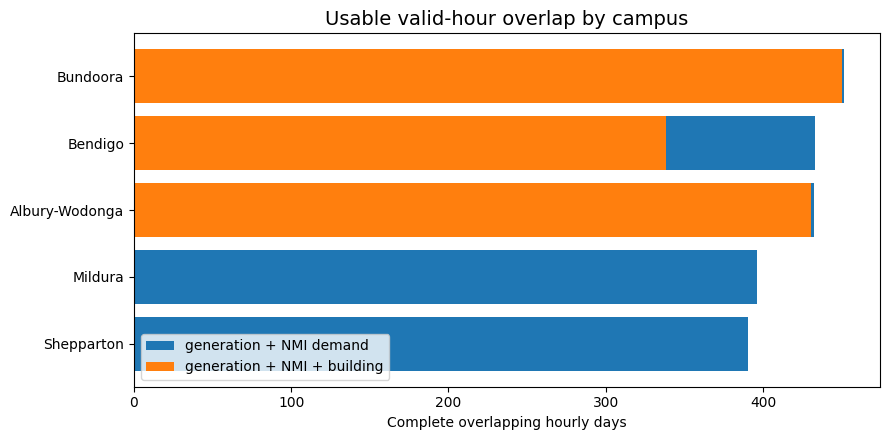

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = overlap_df.sort_values("overlap_gen_nmi_hours")
ax.barh(plot_df["campus_name"], plot_df["overlap_gen_nmi_hours"] / 24, color="tab:blue", label="generation + NMI demand")
ax.barh(plot_df["campus_name"], plot_df["overlap_all_hours"] / 24, color="tab:orange", label="generation + NMI + building")
ax.set_xlabel("Complete overlapping hourly days")
ax.set_title("Usable valid-hour overlap by campus", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
best = overlap_df.iloc[0]
print(
    f"Best-covered campus for hourly prosumption forecasting: {best['campus_name']} "
    f"(campus_id={best['campus_id']}) — {best['overlap_gen_nmi_hours']:.0f} valid-hour "
    f"generation+demand observations (~{best['overlap_gen_nmi_hours'] / 24:.0f} days)."
)
print(
    f"With building consumption also required: {best['overlap_all_hours']:.0f} hours "
    f"(~{best['overlap_all_hours'] / 24:.0f} days)."
)

Best-covered campus for hourly prosumption forecasting: Bundoora (campus_id=1) — 10844 valid-hour generation+demand observations (~452 days).
With building consumption also required: 10800 hours (~450 days).


## 5. Time handling: daylight saving & leap years

Australia's DST transitions (Victoria/NSW, where all five campuses sit) fall on the first
Sunday of April (AEDT → AEST, clocks back — the 1am-2am hour repeats) and the first Sunday of
October (AEST → AEDT, clocks forward — the 2am-3am hour is skipped). Different files in this
dataset handle this differently, checked directly below rather than assumed — a naive local-time
join across files can silently misalign by up to an hour around these dates if the files disagree
on convention.

In [28]:
def describe_day(df, time_col, date_str):
    day = df[df[time_col].dt.date == pd.Timestamp(date_str).date()]
    return len(day), int(day[time_col].duplicated().sum())


aedt_transitions = {
    2018: {"fallback (Apr)": "2018-04-01", "springfwd (Oct)": "2018-10-07"},
    2019: {"fallback (Apr)": "2019-04-07", "springfwd (Oct)": "2019-10-06"},
    2020: {"fallback (Apr)": "2020-04-05", "springfwd (Oct)": "2020-10-04"},
}

In [29]:
# Solar generation: single site, so row counts aren't inflated by multiple sites per campus.
sg_ts = pd.read_csv(
    SOLAR_DIR / "Solar_Energy_Generation.csv", usecols=["SiteKey", "Timestamp"], parse_dates=["Timestamp"]
)
one_site = sg_ts[sg_ts["SiteKey"] == 1]
print("Solar_Energy_Generation.csv (SiteKey=1), expected 96 rows/day at 15-min resolution:")
for label, date in aedt_transitions[2020].items():
    n, dup = describe_day(one_site, "Timestamp", date)
    print(f"  {label} {date}: n={n}, duplicated_timestamps={dup}")
del sg_ts, one_site

Solar_Energy_Generation.csv (SiteKey=1), expected 96 rows/day at 15-min resolution:
  fallback (Apr) 2020-04-05: n=96, duplicated_timestamps=0
  springfwd (Oct) 2020-10-04: n=0, duplicated_timestamps=0


In [30]:
# NMI consumption: single meter, checked across all three years present in the data.
nc_ts = pd.read_csv(
    ARCHIVE_DIR / "nmi_consumption.csv", usecols=["meter_id", "timestamp"], parse_dates=["timestamp"]
)
one_meter = nc_ts[nc_ts["meter_id"] == 1]
print("nmi_consumption.csv (meter_id=1), expected 96 rows/day at 15-min resolution:")
for year, dates in aedt_transitions.items():
    for label, date in dates.items():
        n, dup = describe_day(one_meter, "timestamp", date)
        print(f"  {year} {label} {date}: n={n}, duplicated_timestamps={dup}")
del nc_ts, one_meter

nmi_consumption.csv (meter_id=1), expected 96 rows/day at 15-min resolution:
  2018 fallback (Apr) 2018-04-01: n=96, duplicated_timestamps=0
  2018 springfwd (Oct) 2018-10-07: n=96, duplicated_timestamps=0
  2019 fallback (Apr) 2019-04-07: n=96, duplicated_timestamps=0
  2019 springfwd (Oct) 2019-10-06: n=96, duplicated_timestamps=0
  2020 fallback (Apr) 2020-04-05: n=96, duplicated_timestamps=0
  2020 springfwd (Oct) 2020-10-04: n=96, duplicated_timestamps=0


In [31]:
# Building consumption: union across all meters (any meter reporting), since individual meters
# have their own unrelated gaps that would otherwise be mistaken for a DST effect.
bc_ts = pd.read_csv(ARCHIVE_DIR / "building_consumption.csv", usecols=["timestamp"], parse_dates=["timestamp"])
bc_ts = bc_ts.drop_duplicates()
print("building_consumption.csv (any meter), expected 96 rows/day at 15-min resolution:")
for year, dates in aedt_transitions.items():
    for label, date in dates.items():
        n, dup = describe_day(bc_ts, "timestamp", date)
        print(f"  {year} {label} {date}: n={n} ({n / 4:.0f}h equivalent), duplicated_timestamps={dup}")
del bc_ts

building_consumption.csv (any meter), expected 96 rows/day at 15-min resolution:
  2018 fallback (Apr) 2018-04-01: n=96 (24h equivalent), duplicated_timestamps=0
  2018 springfwd (Oct) 2018-10-07: n=92 (23h equivalent), duplicated_timestamps=0
  2019 fallback (Apr) 2019-04-07: n=96 (24h equivalent), duplicated_timestamps=0
  2019 springfwd (Oct) 2019-10-06: n=92 (23h equivalent), duplicated_timestamps=0
  2020 fallback (Apr) 2020-04-05: n=96 (24h equivalent), duplicated_timestamps=0
  2020 springfwd (Oct) 2020-10-04: n=92 (23h equivalent), duplicated_timestamps=0


In [32]:
# Archive weather: single campus, 1-min resolution -> 1440 rows on a normal 24h day.
aw_ts = pd.read_csv(ARCHIVE_DIR / "weather_data.csv", usecols=["campus_id", "timestamp"], parse_dates=["timestamp"])
one_campus_w = aw_ts[aw_ts["campus_id"] == 1]
print("weather_data.csv (campus_id=1), expected 1440 rows/day at 1-min resolution:")
for year, dates in aedt_transitions.items():
    for label, date in dates.items():
        n, dup = describe_day(one_campus_w, "timestamp", date)
        print(f"  {year} {label} {date}: n={n} ({n / 60:.0f}h equivalent), duplicated_timestamps={dup}")
del aw_ts, one_campus_w

weather_data.csv (campus_id=1), expected 1440 rows/day at 1-min resolution:
  2018 fallback (Apr) 2018-04-01: n=1440 (24h equivalent), duplicated_timestamps=0
  2018 springfwd (Oct) 2018-10-07: n=1380 (23h equivalent), duplicated_timestamps=0
  2019 fallback (Apr) 2019-04-07: n=1440 (24h equivalent), duplicated_timestamps=0
  2019 springfwd (Oct) 2019-10-06: n=1380 (23h equivalent), duplicated_timestamps=0
  2020 fallback (Apr) 2020-04-05: n=1440 (24h equivalent), duplicated_timestamps=0
  2020 springfwd (Oct) 2020-10-04: n=1380 (23h equivalent), duplicated_timestamps=0


**Result**: `Solar_Energy_Generation.csv` and `nmi_consumption.csv` show a flat row count on
every transition date checked — both ignore DST entirely and run on a fixed clock. In contrast,
`building_consumption.csv` and `weather_data.csv` (archive) show a *shorter* day (23h equivalent)
on the October spring-forward date, but **not** a longer day on the April fallback date — they
skip the nonexistent hour but don't duplicate the repeated one. `Solar_Irradiance.csv` sidesteps
the question entirely by storing `Timestamp_UTC` in UTC; `building_submeter_consumption.csv` is
the only file that encodes DST unambiguously, via an explicit UTC offset in the timestamp string
(`+10:00`/`+11:00`).

Practically: the campus-selection analysis above (generation vs. NMI demand) is unaffected, since
both of those series ignore DST the same way. `building_consumption` — used only as a secondary
cross-check — is the one series here that could misalign by up to an hour against the others for a
few hours around each transition.

In [33]:
# Leap years: confirm Feb 29 isn't dropped or double-counted.
sg_leap = pd.read_csv(
    SOLAR_DIR / "Solar_Energy_Generation.csv", usecols=["SiteKey", "Timestamp"], parse_dates=["Timestamp"]
)
one_site_leap = sg_leap[sg_leap["SiteKey"] == 1]
nc_leap = pd.read_csv(ARCHIVE_DIR / "nmi_consumption.csv", usecols=["meter_id", "timestamp"], parse_dates=["timestamp"])
one_meter_leap = nc_leap[nc_leap["meter_id"] == 1]

print("Solar_Energy_Generation.csv (SiteKey=1):")
for date in ["2020-02-28", "2020-02-29", "2020-03-01"]:
    n, _ = describe_day(one_site_leap, "Timestamp", date)
    print(f"  {date}: n={n}")

print("nmi_consumption.csv (meter_id=1):")
for date in ["2016-02-28", "2016-02-29", "2020-02-28", "2020-02-29"]:
    n, _ = describe_day(one_meter_leap, "timestamp", date)
    print(f"  {date}: n={n}")

print(f"calender.csv contains 2016-02-29: {(calendar['date'] == pd.Timestamp('2016-02-29')).any()}")
print(f"calender.csv contains 2020-02-29: {(calendar['date'] == pd.Timestamp('2020-02-29')).any()}")

del sg_leap, one_site_leap, nc_leap, one_meter_leap

Solar_Energy_Generation.csv (SiteKey=1):
  2020-02-28: n=96
  2020-02-29: n=96
  2020-03-01: n=96
nmi_consumption.csv (meter_id=1):
  2016-02-28: n=96
  2016-02-29: n=96
  2020-02-28: n=96
  2020-02-29: n=96
calender.csv contains 2016-02-29: True
calender.csv contains 2020-02-29: True


Feb 29 is present with a normal full day of readings everywhere checked, in both 2016 and 2020 — no leap-year special-casing or drops.

## 6. Summary

- **Coverage**: the solar dataset spans the five La Trobe campuses at 15-min resolution
  (~2019/2020-2022). NMI and building consumption run longer (back to ~2015/2018) at the same
  15-min resolution. The calendar covers 2016-2022 at daily resolution.
- **Linkage**: `campus_meta.csv` is the join key across all campus-scoped files. `nmi_meta.csv`'s
  meter→campus mapping was needed to recover ~4.4% of `nmi_consumption.csv` rows (all from one
  meter) that had a missing `campus_id`.
- **Missing values**: `pct_present` in section 4.1 measures gaps *within* each series' own active
  date range per campus; the valid-hour overlap in 4.2 is the number actually usable for
  paired generation/demand modelling — this is materially smaller than any single series'
  completeness once all three are required simultaneously.
- **Campus choice**: use the ranked table and printed recommendation in section 4 — the top campus
  by `overlap_gen_nmi_hours` is the one with the most simultaneous generation + grid-demand data
  for hourly prosumption forecasting. `building_consumption` is a secondary cross-check (partial
  building coverage can understate true demand), so it isn't used to gate campus choice.
- **BESS relevance**: `nmi_consumption.csv`'s `demand_kW` is the appropriate demand series for
  prosumption (grid-boundary import), not `building_consumption.csv`, which only covers monitored
  buildings. The calendar's holiday/semester/exam flags remain a natural exogenous feature given
  the term-time structure visible in campus load.
- **DST/leap years**: solar generation and NMI consumption (the two series behind the campus
  choice) both ignore DST on a fixed clock, so they stay mutually aligned; `building_consumption`
  and archive `weather_data` are DST-aware and can drift up to an hour against the others around
  the two annual transitions. Leap days are handled correctly everywhere checked.